In [1]:
pip install scikit-learn==1.8.0

# Weekly Class AI/ML Advanced 4th & 5th Session Assignments

Dataset's Information:

[titanic.csv](https://www.kaggle.com/competitions/titanic/data?select=train.csv)

|Variable|Definition|Key|
|:---:|:---:|:---|
|survival|Survival|0 = No, 1 = Yes|
|pclass|Ticket class|1 = 1st, 2 = 2nd, 3 = 3rd|
|sex|Sex||
|Age|Age in years||
|sibsp|# of siblings / spouses aboard the Titanic||
|parch|# of parents / children aboard the Titanic||
|ticket|Ticket number||
|fare|Passenger fare||
|cabin|Cabin number||
|embarked|Port of Embarkation|C = Cherbourg, Q = Queenstown, S = Southampton|

,Survived,Pclass,Sex,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,
1,0,3,male,1,0,7.25,S
2,1,1,female,1,0,712.833,C
3,1,3,female,0,0,7.925,S
4,1,1,female,1,0,53.1,S
5,0,3,male,0,0,08.05,S


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Fare,891,248,08.05,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Survived  891 non-null    int64 
 1   Pclass    891 non-null    int64 
 2   Sex       891 non-null    object
 3   SibSp     891 non-null    int64 
 4   Parch     891 non-null    int64 
 5   Fare      891 non-null    object
 6   Embarked  889 non-null    object
dtypes: int64(4), object(3)
memory usage: 55.7+ KB


None

,0
Survived,0
Pclass,0
Sex,0
SibSp,0
Parch,0
Fare,0
Embarked,2


array([[<Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>]], dtype=object)

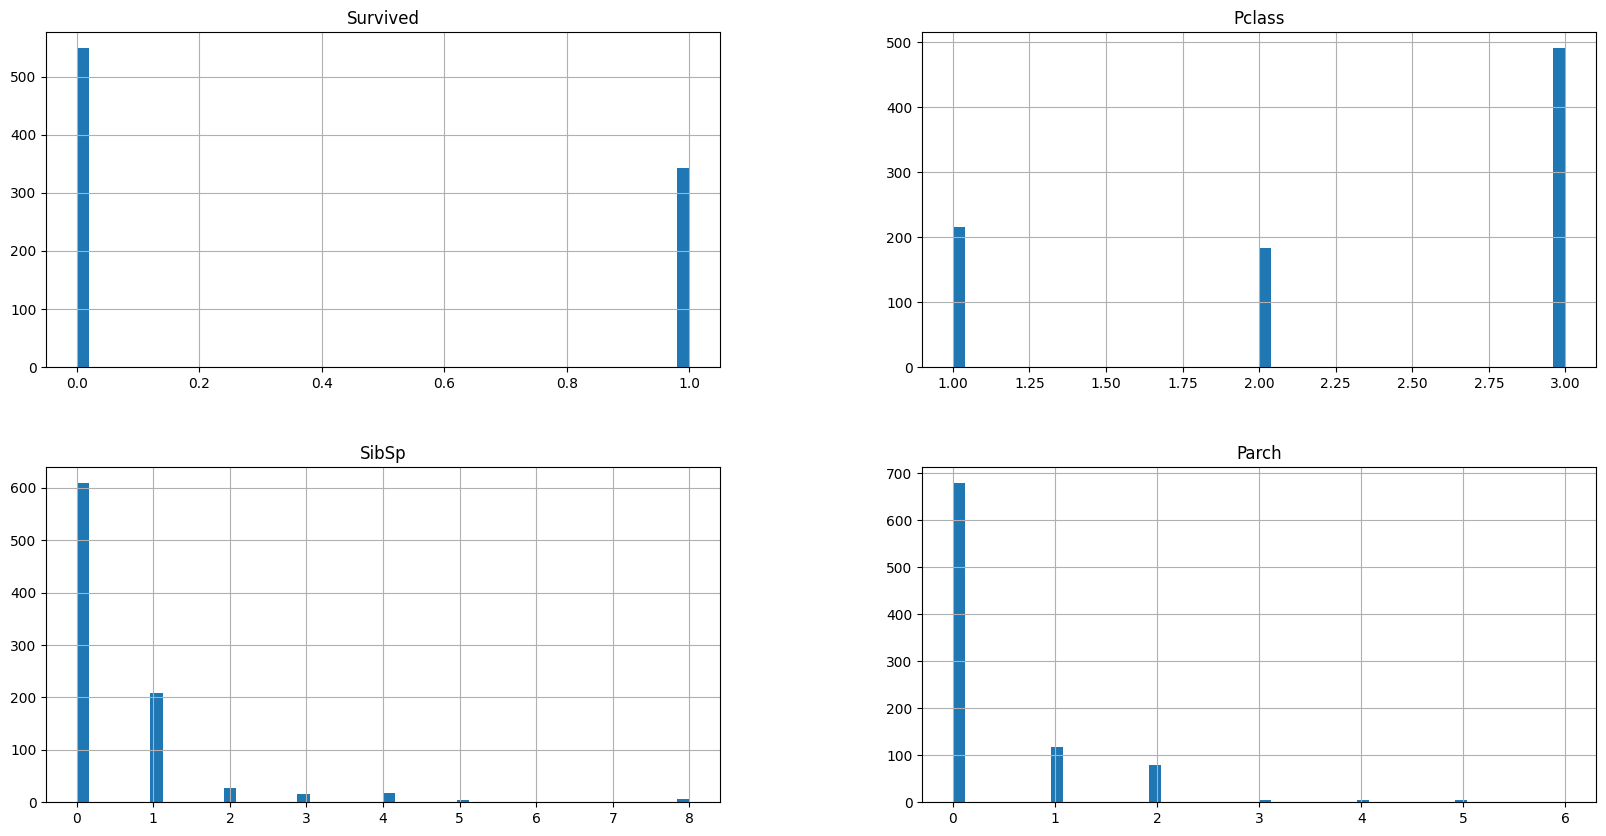

In [2]:
import pandas as pd
import warnings

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

df = pd.read_csv('titanic.csv', index_col='PassengerId')
df.drop(['Name', 'Age', 'Ticket', 'Cabin'], axis=1, inplace=True)

display(df.head())
display(df.describe(include='all').T)
display(df.info())
display(df.isnull().sum())
df.hist(bins=50, figsize=(20,10))

In [3]:
# Pisahkan data sebelum preprocessing
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']

X['Fare'] = (
    X['Fare']
    .astype(str)
    .str.replace('.', '', regex=False)
    .astype(float)
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train: {X_train.shape}\nX_test: {X_test.shape}')
print(f'y_train: {y_train.shape}\ny_test: {y_test.shape}\n')
print(y_train.value_counts(normalize=True), '\n')
print(y_test.value_counts(normalize=True))

X_train: (712, 6)
X_test: (179, 6)
y_train: (712,)
y_test: (179,)

Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64 

Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [4]:
# Data Preprocessing menggunakan Sci-kit Learn Pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, RobustScaler

pipeline_categoric = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

pipeline_numeric = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Tambahan
    ('scaler', MinMaxScaler())
])

pipeline_fare = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Tambahan
    ('scaler', RobustScaler())
])

In [5]:
# Declare ColumnTransformer
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('pipeline_categoric', pipeline_categoric, ['Pclass', 'Sex', 'Embarked']),
        ('pipeline_numeric', pipeline_numeric, ['SibSp', 'Parch']),
        ('pipeline_fare', pipeline_fare, ['Fare'])
    ],
    remainder='passthrough'
)

In [6]:
# Create the core Pipeline + model selection
from sklearn.model_selection import KFold, cross_val_score

# Import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Declare models
models = {
    'Logistic Regression': LogisticRegression(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Save the results for next cell
results = {
    'model': [],
    'avg_scores': [],
    'std_scores': []
}

# Model Selection
for model_name, model in models.items():
    # The core Pipeline
    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    # Calculate the cross-validation scores
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='accuracy')

    # Saving the results
    results['model'].append(model_name)
    results['avg_scores'].append(cv_scores.mean())
    results['std_scores'].append(cv_scores.std())

    # Check the results
    print(f'Cross-Validation results for: {model_name}')
    print(f"{'='*48}\nScores: {cv_scores}")
    print(f'Average Score: {cv_scores.mean()}')
    print(f'Score\'s std: {cv_scores.std()}\n')

Cross-Validation results for: Logistic Regression
Scores: [0.74825175 0.75524476 0.77464789 0.79577465 0.86619718]
Average Score: 0.7880232443612725
Score's std: 0.04244137222512335

Cross-Validation results for: K-Nearest Neighbors
Scores: [0.76223776 0.7972028  0.79577465 0.83098592 0.8028169 ]
Average Score: 0.7978036048458584
Score's std: 0.02188883587079277

Cross-Validation results for: Support Vector Machine
Scores: [0.76223776 0.76223776 0.77464789 0.79577465 0.86619718]
Average Score: 0.7922190485570767
Score's std: 0.03896641487907737

Cross-Validation results for: Decision Tree
Scores: [0.77622378 0.81118881 0.78169014 0.85211268 0.81690141]
Average Score: 0.8076233625529401
Score's std: 0.027337006366651834

Cross-Validation results for: Random Forest
Scores: [0.76223776 0.77622378 0.78169014 0.8028169  0.8028169 ]
Average Score: 0.7851570964247021
Score's std: 0.01575345863297396

Cross-Validation results for: XGBoost
Scores: [0.77622378 0.76923077 0.79577465 0.79577465 0.

In [7]:
# Show model benchmarking as DataFrame
pd.DataFrame(results, index=results['model']).drop('model', axis=1).sort_values(by='avg_scores', ascending=False)

# kita pilih Random Forest

,avg_scores,std_scores
Decision Tree,0.807623,0.027337
XGBoost,0.797823,0.029120
K-Nearest Neighbors,0.797804,0.021889
Support Vector Machine,0.792219,0.038966
Logistic Regression,0.788023,0.042441
Random Forest,0.785157,0.015753


In [8]:
# Import RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Re-declare core Pipeline
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(random_state=42))
    ]
)

# Define hyperparameter combination (search space)
parameter = {
    'model__n_estimators': [100, 200, 300, 400, 500],
    'model__max_depth': [None, 10, 20, 30, 40],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

# Setup RandomizedSearchCV Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=parameter,
    n_iter=20,
    cv=kf,
    scoring='accuracy',
    verbose=1,
    random_state=42,
    return_train_score=True
    )

# Model training
model.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validati

In [9]:
# Check Hyperparameter Tuning result
pd.DataFrame(model.cv_results_).sort_values(by='rank_test_score').head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_estimators,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
13,0.180748,0.008552,0.019571,0.001783,100,5,1,log2,10,"{'model__n_estimators': 100, 'model__min_sampl...",0.762238,0.783217,0.795775,0.823944,0.838028,0.800640,0.027360,1,0.903339,0.903339,0.903509,0.898246,0.889474,0.899581,0.005434
3,0.175089,0.009513,0.018297,0.000791,100,2,4,sqrt,None,"{'model__n_estimators': 100, 'model__min_sampl...",0.755245,0.790210,0.802817,0.809859,0.823944,0.796415,0.023294,2,0.845343,0.847100,0.843860,0.840351,0.843860,0.844103,0.002223
5,0.577099,0.123168,0.043967,0.010162,300,5,2,log2,10,"{'model__n_estimators': 300, 'model__min_sampl...",0.769231,0.790210,0.795775,0.809859,0.816901,0.796395,0.016603,3,0.891037,0.882250,0.885965,0.871930,0.868421,0.879920,0.008504
10,0.495853,0.066957,0.044337,0.002481,200,10,4,sqrt,10,"{'model__n_estimators': 200, 'model__min_sampl...",0.755245,0.790210,0.795775,0.802817,0.830986,0.795006,0.024332,4,0.843585,0.840070,0.847368,0.842105,0.843860,0.843398,0.002398
1,1.076851,0.321127,0.065276,0.013192,500,5,4,log2,40,"{'model__n_estimators': 500, 'model__min_sampl...",0.762238,0.790210,0.788732,0.809859,0.823944,0.794997,0.020948,5,0.847100,0.847100,0.852632,0.842105,0.843860,0.846559,0.003594


In [10]:
# prefer joblib for sklearn models
import joblib

# Save the model as 'model.joblib'
joblib.dump(model, 'model.joblib')

['model.joblib']

In [11]:
from google.colab import files
files.download('model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>